In [1]:
import numpy as np
import sisl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ipywidgets as widgets
from ipywidgets import interact

# Notes

- Make fat-BS
- calculates RSE vs. E for `[0.0, 0.1, 0.2]` (in scatter plot)
- Tiling (N) vs. on-site RSE

**OBS:** Move in $\mathrm{K}_x$ direction for bands

# Global parameters

In [256]:
BOND = 1.42
OUTER_R = BOND

PHI = np.pi/3
B = BOND*np.cos(PHI)
INNER_R = B

KIND = 'armchair'
# KIND = 'zigzag'

N0 = 8
N1 = 4
ETA = 1e-4
NK1 = 400

# E = 0
# dE = 0.01
# EMAX = 0.5
# EMIN = -EMAX
# ENERGIES = np.arange(EMIN, EMAX+dE, dE)
ETAS = np.logspace(-1, -5, num=5)
NUM_E = 1_000

R = (0.1, BOND+1e-2)
T = (0.0, -2.7)
NUM_K = 400


## Global parameters (dependent on previous)

In [ ]:
gr = sisl.geom.graphene_nanoribbon(width=N0, bond=BOND, kind="armchair")
gr = gr.tile(5, 0)
HAM = sisl.Hamiltonian(gr)
HAM.construct([R, T])
HAM.set_nsc([3,1,1])

XYZ = HAM.xyz

BAND_POINTS = [
    [0, 0, 0],
    [0.5, 0, 0],
]
BAND_LABELS = [
    r"$\Gamma$", 
    r'$\mathrm{K}_x$', 
]

BANDS = sisl.BandStructure(HAM, points=BAND_POINTS, divisions=NUM_K, names=BAND_LABELS)
LK, KT, KL = BANDS.lineark(ticks=True)
EIGS = BANDS.apply.array.eigh()
EIGSTATE = HAM.eigenstate()

EMIN = EIGS.min()
EMAX = EIGS.max()
ENERGIES = np.linspace(EMIN, EMAX, NUM_E)
PDOS = EIGSTATE.PDOS(ENERGIES).squeeze()

# Self-energy calculations

(800, 80)
[381 382 383 384 385 386 387 388 389 390 391 392 393 394 395 396 397 398
 399 400 401 402 403 404 405 406 407 408 409 410 411 412 413 414 415 416
 417 418 419 420 421 422 423 424 425 426 427 428 429 430 431 432 433 434
 435 436 437 438 439 440 441 442 443 444 445 446 447 448 449 450 451 452
 453 454 455 456 457 458 459 460 461 462 463 464 465 466 467 468 469 470
 471 472 473 474 475 476 477 478 479 480 481 482 483 484 485 486 487 488
 489 490 491 492 493 494 495 496 497 498 499 500 501 502 503 504 505 506
 507 508 509 510 511 512 513 514 515 516 517 518 519 520 521 522 523 524
 525 526 527 528 529 530 531 532 533 534 535 536 537 538 539 540 541 542
 543 544 545 546 547 548 549 550 551 552 553 554 555 556 557 558 559 560
 561 562 563 564 565 566 567 568 569 570 571 572 573 574 575 576 577 578
 579 580 581 582 583 584 585 586 587 588 589 590 591 592 593 594 595 596
 597 598 599 600 601 602 603 604 605 606 607 608 609 610 611 612 613 614
 615 616 617 618 619 620 621 622 623 624 

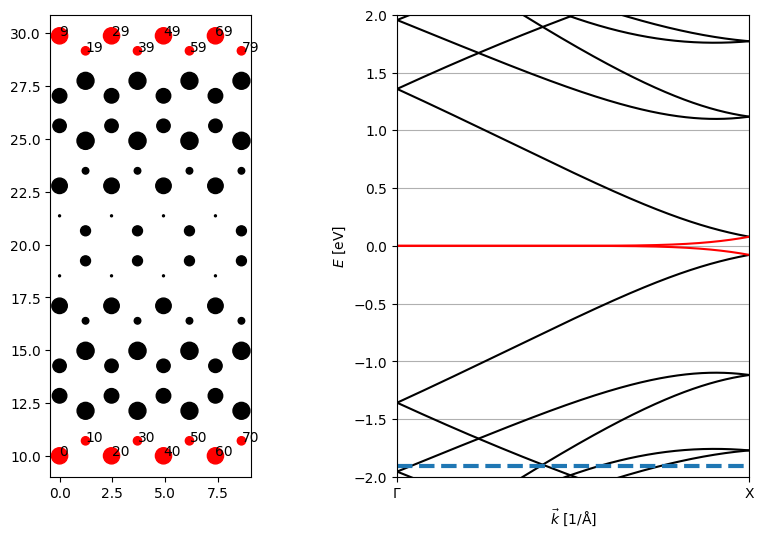

In [ ]:
gr = sisl.geom.graphene_nanoribbon(width=10, bond=BOND, kind='zigzag')
# gr = sisl.geom.graphene(bond=BOND)
# gr = gr.tile(10,1)
gr = gr.tile(4,0)
HAM = sisl.Hamiltonian(gr)


r = (0.1, 1.44)
t = (0.0, -2.7)
HAM.construct([r,t])


bands = sisl.BandStructure(HAM, points=BAND_POINTS, divisions=800, names=BAND_LABELS)
lk, kt, kl = bands.lineark(ticks=True)

eigs = bands.apply.array.eigh()
print(eigs.shape)
# es = bands.apply.array.eigenstate()
es = HAM.eigenstate()
energies = np.linspace(eigs.min(), eigs.max(), num=1_000)
pdos = es.PDOS(energies  ).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10,6))

# print(pdos.shape)
pairs = 1
# eigs = eigs[:, list(range(0, pairs+1)) + list(range(-(pairs+1), 0))]
nbands = eigs.shape[-1]

xyz = gr.xyz
y_coords = xyz[:, 1]
y_max = y_coords.max()
y_min = y_coords.min()
tol = BOND*np.sqrt(3)/2

top_edge_indices, = np.where(np.abs(y_coords - y_max) < tol)
bottom_edge_indices,  = np.where(np.abs(y_coords - y_min) < tol)

edges = np.concatenate([bottom_edge_indices, top_edge_indices])
not_edges = np.delete(np.arange(len(y_coords)), edges)

E = 3
idxs, = np.where(np.isclose(energies, E, atol=tol, rtol=tol))
E_idx = idxs[0]
print(idxs)


axes[0].scatter(xyz[edges, 0], xyz[edges, 1], s=pdos[edges, E_idx]*1e3, c='r')
axes[0].scatter(xyz[not_edges, 0], xyz[not_edges, 1], s=pdos[not_edges, E_idx]*1e3, c='k')
for i in edges:
    x, y, _ = xyz[i, :]
    axes[0].annotate(xy=(x, y), text=i)
axes[0].axis('scaled')


# axes[1].plot(lk, eigs[:, nbands//2-15:nbands//2+15], color="k")
axes[1].plot(lk, eigs[:, not_edges], color="k")
axes[1].plot(lk, eigs[:, edges], color="r")

axes[1].axhline(energies[E_idx], lw=3, linestyle='--')
axes[1].set(xticks=kt, xticklabels=kl, xlim=(lk[0], lk[-1]), xlabel=r"$\vec{k}$ [1/Å]", ylabel="$E$ [eV]")
axes[1].set_ylim(-2,2)
axes[1].grid()

In [243]:
?es.PDOS

Signature: es.PDOS(E, distribution: 'DistributionType' = 'gaussian')
Docstring:
Calculate PDOS for provided energies, `E`.

This routine calls `~sisl.physics.electron.PDOS` with appropriate arguments
and returns the PDOS.

See `~sisl.physics.electron.PDOS` for argument details.
File:      ~/projects/QTM-ML/.venv/lib/python3.13/site-packages/sisl/physics/electron.py
Type:      method

In [217]:
gr.plot(axes='xy')

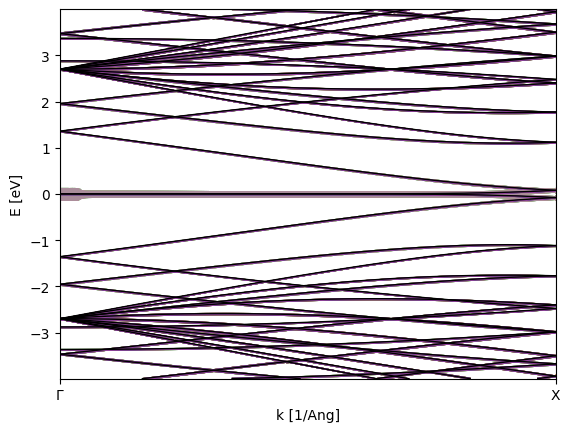

In [230]:
fatplot=bands.plot.fatbands(Erange=[-4, 4], backend="matplotlib")
fatplot.split_orbs(on="atoms", only=edges)


In [ ]:
numk = 300
gr = sisl.geom.graphene_nanoribbon(width=5, bond=BOND, kind='armchair')
# gr = sisl.geom.graphene(bond=BOND)
# gr = gr.tile(10,1)
gr = gr.tile(4,0)
HAM = sisl.Hamiltonian(gr)




r = (0.1, 1.44)
t = (0.0, -2.7)
HAM.construct([r,t])
HAM.set_nsc([3,1,1])

BAND_POINTS = [
    [0, 0, 0],
    [0.5, 0, 0],
    
]
BAND_LABELS = [
    r"$\Gamma$", 
    # r'M', 
    # r"$\Gamma$", 
    r'K_x', 
    # r'$\Gamma$'
]

bands = sisl.BandStructure(HAM, points=BAND_POINTS, divisions=numk, names=BAND_LABELS)
lk, kt, kl = bands.lineark(ticks=True)

xyz = gr.xyz
y_coords = xyz[:, 1]
y_max = y_coords.max()
y_min = y_coords.min()
tol = BOND*np.sqrt(3)/2

top_edge_indices, = np.where(np.abs(y_coords - y_max) < tol)
bottom_edge_indices,  = np.where(np.abs(y_coords - y_min) < tol)

edges = np.concatenate([bottom_edge_indices, top_edge_indices])

not_edges = np.delete(np.arange(len(y_coords)), edges)

E = 2
idxs, = np.where(np.isclose(energies, E, atol=tol, rtol=tol))

# bands = sisl.BandStructure(Ham, points=band_points, divisions=numk, names=band_labels)
# lk, kt, kl = bands.lineark(ticks=True)
kpts = bands.k

eigenenergies = np.zeros(shape=(numk, HAM.na))
eigenstates = np.zeros(shape=(numk, HAM.na, HAM.na), dtype=np.complex128)
edge_weights = np.zeros_like(eigenenergies)

bulk_weights = np.zeros_like(edge_weights)

for i, k in enumerate(kpts):
    Hk = HAM.Hk(k=k, format="array")
    energy, state = np.linalg.eigh(Hk)
    eigenenergies[i, :] = energy
    eigenstates[i, :, :] = state
    
    # state[i, :] corresponds to eigenenergy energy[i]
    c_ik_n = np.abs(state)**2
    edge_contribution = np.sum(c_ik_n[edges], axis=0)
    bulk_contribution = np.sum(c_ik_n[not_edges], axis=0)
    edge_weights[i, :] = edge_contribution
    bulk_weights[i, :] = bulk_contribution
    
print(edge_weights.shape)

(300, 40)


In [249]:
edge_weights[0]

array([0.66666667, 0.66666667, 0.66666667, 0.86297582, 0.83333333,
       0.63702418, 1.        , 1.        , 1.        , 1.        ,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 1.        , 1.        , 0.66666667, 1.        ,
       1.        , 0.66666667, 1.        , 1.        , 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       1.        , 1.        , 1.        , 1.        , 0.56510638,
       0.93489362, 0.83333333, 0.66666667, 0.66666667, 0.66666667])

In [ ]:
HAM.geometry.plot(axes='xy')

[]


(np.float64(-0.781),
 np.float64(16.401),
 np.float64(9.75404878532522),
 np.float64(15.164975508170391))

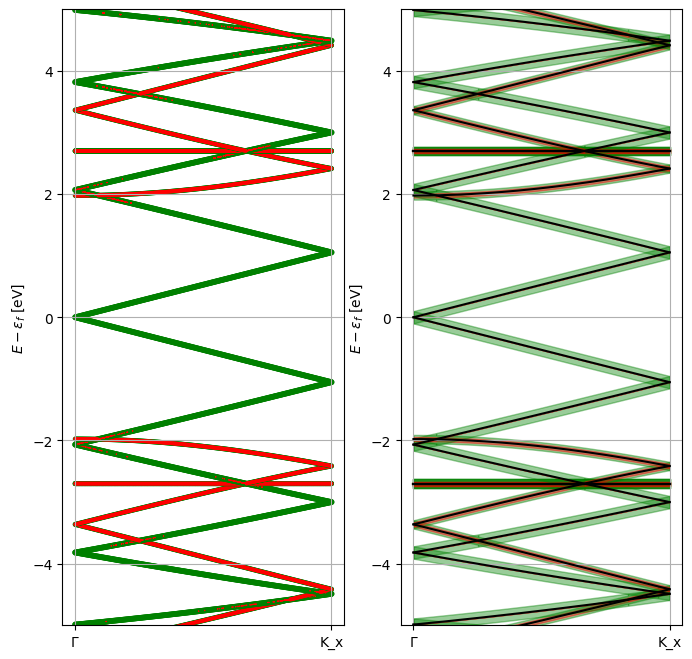

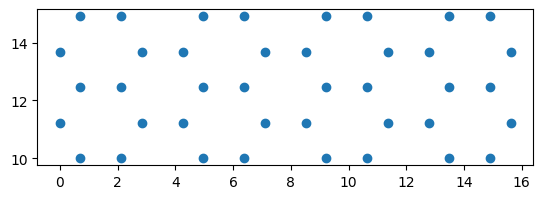

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,8))

# ax.plot(lk, eigenenergies[:, not_edges], color='k')
all_bands = np.arange(HAM.na)
bands_to_plot = np.delete(all_bands, edges)[25:45]
print(bands_to_plot)

axes[1].plot(lk, eigenenergies, c='k')
scale_factor = 0.1
for n in all_bands:
    upper = eigenenergies[:, n] + (edge_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (edge_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='g',
                    alpha=0.4,
                    edgecolor="g")
    
    upper = eigenenergies[:, n] + (bulk_weights[:, n]*scale_factor)
    lower = eigenenergies[:, n] - (bulk_weights[:, n]*scale_factor)
    axes[1].fill_between(lk, lower, upper,
                    color='r',
                    alpha=0.4,
                    edgecolor="r")

for n in range(HAM.na):
    axes[0].scatter(lk, eigenenergies[:, n],
               s=edge_weights[:, n]*1e1,
               c='g'
            #    c=weights[:, n],
            #    cmap='',
            #    edgecolor='g'
               )
    axes[0].scatter(lk, eigenenergies[:, n],
               s=bulk_weights[:, n]*1e1,
               c='r'
            #    c=weights[:, n],
            #    cmap='',
            #    edgecolor='g'
               )

for ax in axes:
    ax.set_ylim((-5,5))
    ax.set_ylabel(r"$E - \epsilon_f$ [eV]")
    ax.set_xticks(kt, kl)
    ax.grid()
    
fig, ax = plt.subplots()

ax.scatter(gr.xyz[:, 0], gr.xyz[:, 1])
ax.axis('scaled')
    


In [ ]:
edge_weights = np.zeros(shape=(numk, HAM.na, HAM.na))
for i, state in enumerate(eigenstates):
    # ci = state@state
    edge_weights[i, :, :] = state@state

In [6]:
?bands.plot.fatbands

Signature:     
bands.plot.fatbands(
    H: Optional[sisl.physics.Hamiltonian] = None,
    extra_vars: collections.abc.Sequence[typing.Union[dict, str]] = (),
    *,
    Erange: 'Optional[tuple[float, float]]' = None,
    E0: 'float' = 0.0,
    E_axis: "Literal['x', 'y']" = 'y',
    bands_range: 'Optional[tuple[int, int]]' = None,
    spin: 'Optional[Literal[0, 1]]' = None,
    bands_style: 'StyleSpec' = {'color': 'black', 'width': 1, 'opacity': 1, 'dash': 'solid'},
    spindown_style: 'StyleSpec' = {'color': 'blue', 'width': 1},
    gap: 'bool' = False,
    gap_tol: 'float' = 0.01,
    gap_color: 'str' = 'red',
    gap_marker: 'dict' = {'size': 7},
    direct_gaps_only: 'bool' = False,
    custom_gaps: 'Sequence[dict]' = [],
    bands_mode: "Literal['line', 'scatter', 'area_line']" = 'line',
    bands_group_legend: 'bool' = True,
    groups: 'OrbitalQueries' = [],
    fatbands_var: 'str' = 'norm2',
    fatbands_mode: "Literal['line', 'scatter', 'area_line']" = 'area_line',
    fatband